# Two-Tower Deep Neural Network (DNN)

Goal:
* understand how to train 2 tower dnn
* demo 


refs:
* Deep Neural Networks for YouTube Recommendations (Youtube paper)
    *  https://static.googleusercontent.com/media/research.google.com/en//pubs/archive/45530.pdf
        * page 2: "The overall system is comprised of two neural networks: one for candidate generation and one for ranking."
* kaggle (recruiting-dataset-in-spanish)
    * https://www.kaggle.com/code/razimbres/two-towers-recommender

* youtube paper

## Introduction

## Dot Product vs Cosine Similarity and Binary Cross-Entropy Loss

In this notebook, the similarity between user and movie embeddings is computed using the **dot product**.

Dot product between two embeddings it is called $z$ the similarity score (**logit**) :

$
z = u \cdot v = \sum_{i=1}^{d} u_i v_i \\
z = log(\frac{p}{1−p}​)
$

Where:

* $u$ = user embedding  
* $v$ = movie embedding  
* $d$ = embedding dimension   

This score $z$ is used directly as input to the Binary Cross-Entropy loss:

```python
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
```

Since the model outputs raw scores (logits), TensorFlow internally applies the sigmoid function to convert scores into probabilities:

Sigmoid:

$
 p =
 \sigma(z)=\frac{1}{1+e^{-z}}
$

Binary Cross-Entropy loss:

$
L = -\left[y\log(\sigma(z)) + (1-y)\log(1-\sigma(z))\right] \\
L = -\left[y\log(p) + (1-y)\log(1-p)\right]
$

Where:

$y$ = true label (0 or 1)

$\sigma(z)$ = predicted probability

$L$ = loss

## Prepare env

```sh
python3 -m venv ~/.venvs/two-tower-env

source ~/.venvs/two-tower-env/bin/activate

pip install --upgrade pip

pip install \
tensorflow \
tensorflow-datasets \
tensorflow-recommenders \
jupyter \
pandas \
matplotlib \
plotly 

pip install tensorflow tensorflow-datasets tensorflow-recommenders

pip install importlib-resources

# NOTE: optional if you are using vs code
pip install ipykernel

# NOTE: optional if you are using vs code
python -m ipykernel install \
--user \
--name twotower-env \
--display-name "Python (twotower)"

```

In [1]:
import os
# NOTE: tensorflow_recommenders still use keras 2 but tensorflow switch to keras 3
# setting keras 2 as keras version for tensorflow env
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_recommenders as tfrs

print("TF:", tf.__version__)
print("TFDS:", tfds.__version__)
print("TFRS:", tfrs.__version__)

TF: 2.16.2
TFDS: 4.9.9
TFRS: v0.7.7


In [2]:
import IPython
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Datasets: Movielens


* MovieLens is a public recommender dataset created by the GroupLens Research.
    * The MovieLens 100K dataset was collected in 1997–1998, so your result:
* It contains user ratings of movies, used to study recommendation algorithms.
* Popular sizes:
    * 100K — small, ideal for learning
    * 1M / 10M / 20M — research-scal

* Widely used for collaborative filtering

* Data

    * ratings table (user interactions) simplified


    | user_id | movie_id | rating | timestamp   |
    |--------|-----------|--------|-------------|
    | 196    | 242       | 3      | 881250949   |
    | 186    | 302       | 4      | 891717742   |
    | 22     | 377       | 1      | 878887116   |
    | 244    | 51        | 2      | 880606923   |
    | 166    | 346       | 5      | 886397596   |

    * movies table (item metadata) simplified


    | movie_id | movie_title        | genres               |
    |-----------|-------------------|----------------------|
    | 242       | Kolya (1996)      | Comedy,Drama         |
    | 302       | L.A. Confidential | Crime,Drama,Thriller |
    | 377       | Heavyweights      | Comedy               |
    | 51        | Legends of Fall   | Drama,Romance        |
    | 346       | Jackie Brown      | Crime,Drama          |

Explanations about vars

* bucket user age

| bucketized_user_age | Actual age range |
|--------------------|------------------|
| 1                  | Under 18         |
| 18                 | 18–24            |
| 25                 | 25–34            |
| 35                 | 35–44            |
| 45                 | 45–49            |
| 50                 | 50–55            |
| 56                 | 56+              |

* user_gender (is_male)
    * True = Male , False = Female

In [3]:
import tensorflow_datasets as tfds
import pandas as pd

ratings_ds = tfds.load(
    "movielens/100k-ratings",
    split="train"
)

movies_ds = tfds.load(
    "movielens/100k-movies",
    split="train"
)

# Count rows
ratings_size = tf.data.Dataset.cardinality(ratings_ds).numpy()
movies_size = tf.data.Dataset.cardinality(movies_ds).numpy()


print(f"Ratings: size: {ratings_size}; type of: {type(ratings_ds)}")
print(f"Movies: size: {movies_size}; type of: {type(movies_ds)}")


ratings =  pd.DataFrame([{k: v.numpy() for k, v in x.items()} for x in ratings_ds])

users = ratings[["user_id", "user_occupation_text", "user_zip_code", "user_gender", "raw_user_age", "bucketized_user_age"]].drop_duplicates()
movies = pd.DataFrame([{k: v.numpy() for k, v in x.items()} for x in movies_ds])


ratings.head(3)
print()
users.head(3)
print()
movies.head(3)

Ratings: size: 100000; type of: <class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
Movies: size: 1682; type of: <class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


2026-05-05 22:37:07.481788: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-05 22:37:07.801306: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,bucketized_user_age,movie_genres,movie_id,movie_title,raw_user_age,timestamp,user_gender,user_id,user_occupation_label,user_occupation_text,user_rating,user_zip_code
0,45.0,[7],b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",46.0,879024327,True,b'138',4,b'doctor',4.0,b'53211'
1,25.0,"[4, 14]",b'709',b'Strictly Ballroom (1992)',32.0,875654590,True,b'92',5,b'entertainment',2.0,b'80525'
2,18.0,[4],b'412',"b'Very Brady Sequel, A (1996)'",24.0,882075110,True,b'301',17,b'student',4.0,b'55439'


,user_id,user_occupation_text,user_zip_code,user_gender,raw_user_age,bucketized_user_age
0,b'138',b'doctor',b'53211',True,46.0,45.0
1,b'92',b'entertainment',b'80525',True,32.0,25.0
2,b'301',b'student',b'55439',True,24.0,18.0


,movie_genres,movie_id,movie_title
0,[4],b'1681',b'You So Crazy (1994)'
1,"[4, 7]",b'1457',b'Love Is All There Is (1996)'
2,"[1, 3]",b'500',b'Fly Away Home (1996)'


In [4]:
print("ratings table sample:")
ratings_sample = ratings.sample(3)

_cols_view = ["user_id", "user_gender","raw_user_age", "user_occupation_text","user_zip_code" ,"movie_id", "movie_title", "user_rating", "timestamp" ]
ratings_sample[_cols_view]

ratings table sample:


,user_id,user_gender,raw_user_age,user_occupation_text,user_zip_code,movie_id,movie_title,user_rating,timestamp
64378,b'399',True,25.0,b'other',b'92374',b'320',b'Paradise Lost: The Child Murders at Robin Ho...,3.0,882342537
70663,b'716',False,36.0,b'administrator',b'44265',b'82',b'Jurassic Park (1993)',5.0,879796138
75129,b'727',True,25.0,b'student',b'78741',b'435',b'Butch Cassidy and the Sundance Kid (1969)',3.0,883710687


## Preprocessing

In [5]:
# NOTE: based on LLM
# 4 → Children's
# 7 → Documentary
# 11 → Horror
# 15 → Sci-Fi
genres = [g for g in movies["movie_genres"].explode().unique() if g]

len(genres)

genres
max(genres)

_PADDING_GENRE_VALUE = max(genres) + 1

18

[4, 7, 1, 3, 5, 17, 14, 18, 16, 8, 10, 15, 12, 13, 2, 19, 9, 6]

19

In [6]:
import re

def extract_movie_year(title):

    title = title.decode("utf-8") if isinstance(title, bytes) else str(title)
    m = re.search(r"\((\d{4})\)$", title)

    return int(m.group(1)) if m else None


def bucket_movie_year(year):

    if pd.isna(year):
        return "unknown"   # 👈 important

    if year < 1960:
        return "pre_1960"
    elif year < 1970:
        return "1960s"
    elif year < 1980:
        return "1970s"
    elif year < 1990:
        return "1980s"
    elif year < 2000:
        return "1990s"
    elif year < 2010:
        return "2000s"
    elif year < 2020:
        return "2010s"
    else:
        return "2020s_newer"


_MAX_GENRES_PER_MOVIE = 5
def padding_genres(genres, max_genres=_MAX_GENRES_PER_MOVIE):
    genres = list(genres)  # convert numpy array -> python list

    if len(genres) < max_genres:
        genres = genres + [_PADDING_GENRE_VALUE] * (max_genres - len(genres))

    return genres[:max_genres]

def preprocess(data: pd.DataFrame) -> pd.DataFrame:

    data['interaction_date'] = pd.to_datetime(data['timestamp'], unit='s')
    data['user_age_bucket'] =  data['bucketized_user_age'].astype("float32")
    data['is_male_user'] = data['user_gender'].astype("float32")
    # NOTE: convert as floating point number to avoid issues with tensorflow when using as label
    data['label'] = (data['user_rating'] >= 4.0).astype("float32")

    # NOTE: normalize genres list size
    data['movie_genres'] = data['movie_genres'].map(lambda g: padding_genres(g))

    data['movie_year'] = data['movie_title'].apply(extract_movie_year)
    data['movie_year_bucket'] = data['movie_year'].apply(bucket_movie_year)

    return data

ratings = preprocess(ratings)

ratings.head()

,bucketized_user_age,movie_genres,movie_id,movie_title,raw_user_age,timestamp,user_gender,user_id,user_occupation_label,user_occupation_text,user_rating,user_zip_code,interaction_date,user_age_bucket,is_male_user,label,movie_year,movie_year_bucket
0,45.0,"[7, 20, 20, 20, 20]",b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",46.0,879024327,True,b'138',4,b'doctor',4.0,b'53211',1997-11-08 21:25:27,45.0,1.0,1.0,1975.0,1970s
1,25.0,"[4, 14, 20, 20, 20]",b'709',b'Strictly Ballroom (1992)',32.0,875654590,True,b'92',5,b'entertainment',2.0,b'80525',1997-09-30 21:23:10,25.0,1.0,0.0,1992.0,1990s
2,18.0,"[4, 20, 20, 20, 20]",b'412',"b'Very Brady Sequel, A (1996)'",24.0,882075110,True,b'301',17,b'student',4.0,b'55439',1997-12-14 04:51:50,18.0,1.0,1.0,1996.0,1990s
3,50.0,"[5, 7, 20, 20, 20]",b'56',b'Pulp Fiction (1994)',50.0,883326919,True,b'60',4,b'healthcare',4.0,b'06472',1997-12-28 16:35:19,50.0,1.0,1.0,1994.0,1990s
4,50.0,"[10, 16, 20, 20, 20]",b'895',b'Scream 2 (1997)',55.0,891409199,True,b'197',18,b'technician',3.0,b'75094',1998-04-01 05:39:59,50.0,1.0,0.0,1997.0,1990s


## EDA

In [7]:
# NOTE: print data tyoes of all fields in ratings_sample
print("Ratings sample data types:")
for col in ratings.columns:
    print(f"{col}: {ratings[col].dtype}")


Ratings sample data types:
bucketized_user_age: float32
movie_genres: object
movie_id: object
movie_title: object
raw_user_age: float32
timestamp: int64
user_gender: bool
user_id: object
user_occupation_label: int64
user_occupation_text: object
user_rating: float32
user_zip_code: object
interaction_date: datetime64[s]
user_age_bucket: float32
is_male_user: float32
label: float32
movie_year: float64
movie_year_bucket: str


In [8]:
print(f"ratings period: from {ratings['interaction_date'].min()} to {ratings['interaction_date'].max()}")

ratings period: from 1997-09-20 03:05:10 to 1998-04-22 23:10:38


### rating distributions

In [9]:
import numpy as np
import plotly.express as px

# NOTE: Get all 100k ratings as one NumPy array
ratings_np = ratings['user_rating'].to_numpy()

ratings_np.shape

fig = px.histogram(
    x=ratings_np,
    nbins=10,
    title="MovieLens Rating Distribution",
    labels={"x": "User rating", "y": "Count"},
)

fig.show()

(100000,)

### Genres

In [10]:
genre_map = {
    0: "unknown",
    1: "Action",
    2: "Adventure",
    3: "Animation",
    4: "Children's",
    5: "Comedy",
    6: "Crime",
    7: "Documentary",
    8: "Drama",
    9: "Fantasy",
    10: "Film-Noir",
    11: "Horror",
    12: "Musical",
    13: "Mystery",
    14: "Romance",
    15: "Sci-Fi",
    16: "Thriller",
    17: "War",
    18: "Western",
}

movies.movie_genres[0:11]

0        [4]
1     [4, 7]
2     [1, 3]
3        [0]
4        [7]
5        [5]
6        [7]
7        [7]
8        [7]
9       [17]
10       [7]
Name: movie_genres, dtype: object

In [11]:
from collections import Counter
import pandas as pd

_PADDING_GENRE_VALUE = 20

def user_rating_genire_eda(
    ratings: pd.DataFrame,
    high_threshold=4.0,
    low_threshold=2.5,
    top_k=3,
    padding_value=_PADDING_GENRE_VALUE,
) -> pd.DataFrame:

    def top_genres(series):
        counter = Counter()

        for genres in series:
            valid_genres = [g for g in genres if g != padding_value]
            counter.update(valid_genres)

        return [genre for genre, _ in counter.most_common(top_k)]

    user_summary = (
        ratings
        .groupby("user_id")
        .agg(
            interactions=("user_rating", "size"),
            high_rate=("user_rating", lambda x: (x >= high_threshold).sum()),
            low_rate=("user_rating", lambda x: (x < low_threshold).sum()),
        )
        .reset_index()
    )

    high_genres = (
        ratings[ratings["user_rating"] >= high_threshold]
        .groupby("user_id")["movie_genres"]
        .apply(top_genres)
        .reset_index(name="top_3_high_rate_genres")
    )

    low_genres = (
        ratings[ratings["user_rating"] < low_threshold]
        .groupby("user_id")["movie_genres"]
        .apply(top_genres)
        .reset_index(name="top_3_low_rate_genres")
    )

    out = (
        user_summary
        .merge(high_genres, on="user_id", how="left")
        .merge(low_genres, on="user_id", how="left")
    )

    out["top_3_high_rate_genres"] = out["top_3_high_rate_genres"].apply(
        lambda x: x if isinstance(x, list) else []
    )
    out["top_3_low_rate_genres"] = out["top_3_low_rate_genres"].apply(
        lambda x: x if isinstance(x, list) else []
    )

    return out.sort_values("interactions", ascending=False)

user_genre_eda = user_rating_genire_eda(ratings)

user_genre_eda.head()

,user_id,interactions,high_rate,low_rate,top_3_high_rate_genres,top_3_low_rate_genres
340,b'405',737,116,558,"[7, 4, 0]","[7, 4, 0]"
617,b'655',685,114,181,"[7, 16, 14]","[7, 4, 14]"
34,b'13',636,269,213,"[7, 4, 0]","[4, 10, 0]"
390,b'450',540,378,31,"[7, 4, 14]","[4, 7, 3]"
196,b'276',518,274,82,"[7, 4, 0]","[0, 4, 16]"


### Horror movies

In [12]:
_HORROR_KEYWORDS = "Scream|Shining|Exorcist|Halloween|Nightmare|Alien|Evil|Massacre|Dead"

def get_best_horror_movie_for_user(user_id, ratings, movies):
    movies = movies.copy()
    movies["title_str"] = movies["movie_title"].str.decode("utf-8")

    horror_mask = movies["title_str"].str.contains(
        _HORROR_KEYWORDS,
        case=False, na=False
    )

    horror_ids = set(movies[horror_mask]["movie_id"])

    user_rows = ratings[
        (ratings["user_id"] == user_id) &
        (ratings["user_rating"] >= 4.0) &
        (ratings["movie_id"].isin(horror_ids))
    ]

    if len(user_rows) == 0:
        return None

    best = user_rows.sort_values("user_rating", ascending=False).iloc[0]

    return movies[movies["movie_id"] == best["movie_id"]]

best_horror_608 = get_best_horror_movie_for_user(b"608", ratings, movies)

best_horror_608

,movie_genres,movie_id,movie_title,title_str
880,[7],b'196',b'Dead Poets Society (1989)',Dead Poets Society (1989)


In [13]:
# movies[movies["movie_title"].str.decode("utf-8").str.contains("Star", case=False, na=False)][
#     ["movie_id", "movie_title", "movie_genres"]
# ]

# movies[movies["movie_title"].str.decode("utf-8").str.contains("Nightmare", case=False, na=False)][
#     ["movie_id", "movie_title"]
# ]

# movies[movies["movie_title"].str.decode("utf-8").str.contains("Dead", case=False, na=False)][
#     ["movie_id", "movie_title"]
# ]


# movies[movies["movie_title"].str.decode("utf-8").str.contains("Exorcist", case=False, na=False)][
#     ["movie_id", "movie_title"]
# ]

movies[movies["movie_title"].str.decode("utf-8").str.contains("Scream", case=False, na=False)][
    ["movie_id", "movie_title"]
]



ratings[ratings["movie_id"] == b'357'][
    ["movie_id", "movie_title", "movie_year_bucket"]
]

,movie_id,movie_title
43,b'760',b'Screamers (1995)'
204,b'1682',b'Scream of Stone (Schrei aus Stein) (1991)'
471,b'895',b'Scream 2 (1997)'
1041,b'288',b'Scream (1996)'
1269,b'695',b'Kicking and Screaming (1995)'


,movie_id,movie_title,movie_year_bucket
0,b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",1970s
755,b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",1970s
1908,b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",1970s
2309,b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",1970s
2675,b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",1970s
...,...,...,...
98536,b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",1970s
99294,b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",1970s
99418,b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",1970s
99666,b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",1970s


In [14]:
import pandas as pd

def _find_horror_fans_and_scifi_haters(ratings: pd.DataFrame, movies: pd.DataFrame) -> pd.DataFrame:

    # helper to decode titles
    movies["title_str"] = movies["movie_title"].str.decode("utf-8")

    # 1. define horror + sci-fi sets
    horror_movies = movies[
        movies["title_str"].str.contains(
            "Nightmare|Scream|Psycho|Shining|Exorcist|Halloween|Death|Freddy|Jason|Friday the 13th|Saw",
            case=False, na=False
        )
    ]["movie_id"]

    scifi_movies = movies[
        movies["title_str"].str.contains(
            "Star Wars|Empire Strikes|Return of the Jedi|Alien|Blade Runner|Matrix|Terminator|Jedi|Interstellar|Inception|Back to the Future|Star Trek|Hitchhiker's Guide",
            case=False, na=False
        )
    ]["movie_id"]

    # 2. prepare ratings
    ratings_df = ratings.copy()
    ratings_df["movie_id_str"] = ratings_df["movie_id"]

    # 3. flag categories
    ratings_df["is_horror"] = ratings_df["movie_id_str"].isin(horror_movies)
    ratings_df["is_scifi"] = ratings_df["movie_id_str"].isin(scifi_movies)

    # 4. aggregate per user
    
    user_stats = ratings_df.groupby("user_id").agg(
        horror_mean=("user_rating", lambda x: x[ratings_df.loc[x.index, "is_horror"]].mean()),
        scifi_mean=("user_rating", lambda x: x[ratings_df.loc[x.index, "is_scifi"]].mean()),
        horror_count=("is_horror", "sum"),
        scifi_count=("is_scifi", "sum"),
    ).reset_index()

    # 5. filter strong horror fans (tune thresholds)
    horror_fans = user_stats[
        (user_stats["horror_mean"] >= 4.0) &
        (user_stats["scifi_mean"] <= 3.0) &
        (user_stats["horror_count"] >= 2)
    ]

    return horror_fans

# top candidates
horror_fans = _find_horror_fans_and_scifi_haters(ratings, movies)
horror_fans.sort_values("horror_mean", ascending=False)


,user_id,horror_mean,scifi_mean,horror_count,scifi_count
68,b'160',5.0,3.000,2,4
119,b'206',5.0,1.000,2,1
157,b'240',5.0,3.000,2,1
315,b'383',5.0,3.000,2,1
565,b'608',5.0,1.750,3,4
188,b'269',4.5,2.200,2,10
350,b'414',4.5,2.000,2,1
152,b'236',4.0,2.875,2,8
201,b'280',4.0,3.000,3,15
311,b'38',4.0,1.000,3,2


### movie year 

In [15]:
ratings.movie_year_bucket.value_counts()

movie_year_bucket
1990s       69452
1980s       12833
pre_1960     7328
1970s        6448
1960s        3909
unknown        30
Name: count, dtype: int64

### movies ranked by popularity

In [16]:
def get_top_popular_movies(ratings, movies, top_k=15):
    df = ratings.copy()

    # define positive
    df["is_positive"] = (df["user_rating"] >= 4.0).astype(int)

    # aggregate
    movie_stats = (
        df.groupby("movie_id")
        .agg(
            total_ratings=("user_rating", "count"),
            positive_ratings=("is_positive", "sum"),
            avg_rating=("user_rating", "mean"),
        )
        .reset_index()
    )

    # popularity score (simple + effective)
    movie_stats["popularity_score"] = (
        movie_stats["positive_ratings"] * np.log1p(movie_stats["total_ratings"])
    )

    # merge title
    movie_stats = movie_stats.merge(
        movies[["movie_id", "movie_title"]],
        on="movie_id",
        how="left"
    )

    # decode title
    movie_stats["movie_title_str"] = movie_stats["movie_title"].apply(
        lambda x: x.decode("utf-8") if isinstance(x, bytes) else str(x)
    )

    # sort
    return movie_stats.sort_values(
        "popularity_score", ascending=False
    ).head(top_k)



top_movies = get_top_popular_movies(ratings, movies, top_k=20)
top_movies[["movie_title_str", "total_ratings", "positive_ratings", "avg_rating"]]

,movie_title_str,total_ratings,positive_ratings,avg_rating
1128,Star Wars (1977),583,501,4.358490
2,Fargo (1996),508,406,4.155512
774,Return of the Jedi (1983),507,379,4.007890
859,Contact (1997),509,344,3.803536
301,"Godfather, The (1972)",413,351,4.283293
766,Raiders of the Lost Ark (1981),420,348,4.252381
1660,"Silence of the Lambs, The (1991)",390,344,4.289743
0,Toy Story (1995),452,321,3.878319
890,"English Patient, The (1996)",481,298,3.656965
1194,Pulp Fiction (1994),394,294,4.060914


## Split train n test

In [17]:
split_date = pd.Timestamp("1998-03-15")
train_data = ratings[ratings['interaction_date'] < split_date]
# shuffle train data
train_data = train_data.sample(frac=1, random_state=42)

test_data = ratings[ratings['interaction_date'] >= split_date]

print(f"Train data: {len(train_data)} rows; from {train_data['interaction_date'].min()} to {train_data['interaction_date'].max()}")
print(f"Test data: {len(test_data)} rows; from {test_data['interaction_date'].min()} to {test_data['interaction_date'].max()}")

# NOTE: counting #positive case in both train and test data
num_positive_train = (train_data['label'] == 1.0).sum()
num_positive_test = (test_data['label'] == 1.0).sum()

print(f"train data: {num_positive_train} positive cases out of {len(train_data)} total rows ({num_positive_train / len(train_data) * 100:.2f}%)")
print(f"test data: {num_positive_test} positive cases out of {len(test_data)} total rows ({num_positive_test / len(test_data) * 100:.2f}%)")

Train data: 82073 rows; from 1997-09-20 03:05:10 to 1998-03-14 22:14:47
Test data: 17927 rows; from 1998-03-15 04:20:29 to 1998-04-22 23:10:38
train data: 45202 positive cases out of 82073 total rows (55.08%)
test data: 10173 positive cases out of 17927 total rows (56.75%)


**Note:** Both splits are roughly balanced (~55% positive class). This justifies using **binary accuracy** as a metric — in heavily imbalanced datasets accuracy would be misleading (a model predicting all-negative could score high), but here it is a reasonable first-pass simplification.

In [18]:
# NOTE: user ids is in test but not in train data
test_user_ids = set(test_data['user_id'].unique())
train_user_ids = set(train_data['user_id'].unique())

cold_start_user_ids = test_user_ids - train_user_ids

print(f"Number of unique user ids in train data: {len(train_user_ids)}")
print(f"Number of unique user ids in test data: {len(test_user_ids)}")
print(f"Number of user ids in test data but not in train data: {len(cold_start_user_ids)}")


# NOTE:
test_with_no_cold_start = test_data[~test_data['user_id'].isin(cold_start_user_ids)]
test_with_no_cold_start.shape
num_positive_test_with_no_cold_start = (test_with_no_cold_start['label'] == 1.0).sum()
print(f"test data with no cold start users: {num_positive_test_with_no_cold_start} positive cases out of {len(test_with_no_cold_start)} total rows ({num_positive_test_with_no_cold_start / len(test_with_no_cold_start) * 100:.2f}%)")
print(f"Test data with no cold start users: {len(test_with_no_cold_start)} rows; from {test_with_no_cold_start['interaction_date'].min()} to {test_with_no_cold_start['interaction_date'].max()}")


Number of unique user ids in train data: 767
Number of unique user ids in test data: 269
Number of user ids in test data but not in train data: 176


(1985, 18)

test data with no cold start users: 1125 positive cases out of 1985 total rows (56.68%)
Test data with no cold start users: 1985 rows; from 1998-03-15 04:20:29 to 1998-04-22 21:40:38


In [19]:
test_with_no_cold_start


,bucketized_user_age,movie_genres,movie_id,movie_title,raw_user_age,timestamp,user_gender,user_id,user_occupation_label,user_occupation_text,user_rating,user_zip_code,interaction_date,user_age_bucket,is_male_user,label,movie_year,movie_year_bucket
27,50.0,"[4, 20, 20, 20, 20]",b'116',b'Cold Comfort Farm (1995)',51.0,891639552,False,b'891',2,b'administrator',3.0,b'03062',1998-04-03 21:39:12,50.0,0.0,0.0,1995.0,1990s
44,18.0,"[7, 14, 20, 20, 20]",b'794',b'It Could Happen to You (1994)',20.0,893213019,False,b'416',17,b'student',5.0,b'92626',1998-04-22 02:43:39,18.0,0.0,1.0,1994.0,1990s
108,25.0,"[4, 10, 20, 20, 20]",b'208',b'Young Frankenstein (1974)',31.0,890181185,True,b'653',6,b'executive',3.0,b'55105',1998-03-18 00:33:05,25.0,1.0,0.0,1974.0,1970s
140,25.0,"[7, 20, 20, 20, 20]",b'880',b'Soul Food (1997)',26.0,892718919,False,b'708',8,b'homemaker',3.0,b'96349',1998-04-16 09:28:39,25.0,0.0,0.0,1997.0,1990s
177,25.0,"[0, 15, 18, 20, 20]",b'121',b'Independence Day (ID4) (1996)',26.0,891721815,True,b'94',17,b'student',2.0,b'71457',1998-04-04 20:30:15,25.0,1.0,0.0,1996.0,1990s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99726,25.0,"[0, 16, 20, 20, 20]",b'572',b'Blown Away (1994)',26.0,891723883,True,b'94',17,b'student',3.0,b'71457',1998-04-04 21:04:43,25.0,1.0,0.0,1994.0,1990s
99731,18.0,"[4, 20, 20, 20, 20]",b'249',b'Austin Powers: International Man of Mystery ...,20.0,891214777,True,b'332',17,b'student',3.0,b'40504',1998-03-29 23:39:37,18.0,1.0,0.0,1997.0,1990s
99847,35.0,"[3, 4, 20, 20, 20]",b'94',b'Home Alone (1990)',39.0,891036181,True,b'210',18,b'engineer',4.0,b'03060',1998-03-27 22:03:01,35.0,1.0,1.0,1990.0,1990s
99882,18.0,"[7, 20, 20, 20, 20]",b'310',"b'Rainmaker, The (1997)'",18.0,891961663,True,b'851',11,b'other',5.0,b'29646',1998-04-07 15:07:43,18.0,1.0,1.0,1997.0,1990s


## Define two towers arch

* inputs -> feature encoding -> dense representation -> final embedding
* user embedding · movie embedding = score 
    * good pair → higher dot product
    * bad pair → lower dot product

In [20]:
OUTPUT_EMBEDDING_DIM = 21 # NOTE: dim of user and movie embeddings output by the towers


def ee_dim(vocab_size):
    return int(np.ceil(np.sqrt(vocab_size))) + 1

### User tower

* **TODO**:
    * Still need to add iteration features

```
                         User Tower

   user_id              user_age_bucket              is_male
  (string)                  (int)                    (float)
     |                        |                         |
     v                        v                         v
+-------------+        +---------------+                |
| StringLookup|        | IntegerLookup |                |
+-------------+        +---------------+                |
     |                        |                         |
     v                        v                         |
+-------------+        +---------------+                |
| Embedding   |        | Embedding     |                |
| (EMBED_DIM) |        | (dim=8)       |                |
+-------------+        +---------------+                |
     |                        |                         |
     +------------------------+-------------------------+
                              |
                              v
                     +-------------------+
                     |   Concatenate     |
                     | (batch, D + 8 + 1)|
                     +-------------------+
                              |
                              v
                     +-----------------------+
                     |  Dense(20, relu) + L2 |
                     +-----------------------+
                              |
                              v
                     +-----------------------+
                     |     Dropout(0.35)     |
                     +-----------------------+
                              |
                              v
                     +-----------------------+
                     |  Dense(EMBEDDING_DIM) |
                     +-----------------------+
                              |
                              v
                     +-----------------------+
                     |    User Embedding     | ───> dot product with Movie Embedding
                     |   (EMBEDDING_DIM,)    |
                     +-----------------------+                                        
```

In [21]:
import tensorflow as tf

class UserEmbeddingBlock(tf.keras.Model):

    def __init__(self, users, age_vocab, occupation_vocab, embedding_dim):

        super().__init__()

        # encoders
        self.user_id_encoder = tf.keras.layers.StringLookup(
            vocabulary=users,
            mask_token=None
        )

        self.age_encoder = tf.keras.layers.IntegerLookup(
            vocabulary=age_vocab,
            mask_token=None
        )

        self.occupation_encoder = tf.keras.layers.StringLookup(
            vocabulary=occupation_vocab,
            mask_token=None
        )

        # embeddings
        self.user_id_ee_dim = ee_dim(len(users))
        self.user_id_embedding = tf.keras.layers.Embedding(
            input_dim=len(users) + 1,
            output_dim=int(self.user_id_ee_dim)
        )

        self.age_ee_dim = ee_dim(len(age_vocab))
        self.age_embedding = tf.keras.layers.Embedding(
            input_dim=len(age_vocab) + 1,
            output_dim=int(self.age_ee_dim)
        )

        self.occupation_ee_dim = ee_dim(len(occupation_vocab))
        self.occupation_embedding = tf.keras.layers.Embedding(
            input_dim=len(occupation_vocab) + 1,
            output_dim=int(self.occupation_ee_dim)
        )

    def call(self, X):

        user_id = X["user_id"]
        user_age = tf.cast(X["user_age_bucket"], tf.int32)
        user_gender = X["is_male_user"]
        user_occupation = X["user_occupation_text"]

        # encode
        user_id_idx = self.user_id_encoder(user_id)
        age_idx = self.age_encoder(user_age)
        occupation_idx = self.occupation_encoder(user_occupation)
        # internal user id embeddings: shape (batch,) -> (batch, embedding_dim)
        user_emb = self.user_id_embedding(user_id_idx)
        # internal age embeddings: shape (batch,) -> (batch, 8)
        age_emb = self.age_embedding(age_idx)
        # internal occupation embeddings: shape (batch,) -> (batch, 8)
        occupation_emb = self.occupation_embedding(occupation_idx)

        # reshape gender: shape: (batch,) -> (batch, 1)
        user_gender = tf.expand_dims(user_gender, axis=-1)

        # [debug]
        # tf.print("user_emb shape:", tf.shape(user_emb))
        # tf.print("age_emb shape:", tf.shape(age_emb))
        # tf.print("occupation_emb shape:", tf.shape(occupation_emb))
        # tf.print("user_gender shape:", tf.shape(user_gender))

        # concat all internal embeddings in one single tensor
        x = tf.concat([user_emb, age_emb, occupation_emb, user_gender],axis=1)

        return x


class UserTower(tf.keras.Model):

    def __init__(self, users, age_vocab, occupation_vocab, embedding_dim=OUTPUT_EMBEDDING_DIM):

        super().__init__()

        self.unique_users = users
        self._n_unique_users = len(users)

        self.unique_ages = age_vocab
        self._n_unique_ages = len(age_vocab)

        self.unique_occupations = occupation_vocab
        self._n_unique_occupations = len(occupation_vocab)

        self.embedding_dim = embedding_dim

        self.dnn = None
        self._build_dnn()

    def _build_dnn(self) -> None:

        # internal embedding layers
        self.embedding_layers = UserEmbeddingBlock(
            self.unique_users,
            self.unique_ages,
            self.unique_occupations,
            self.embedding_dim
        )

        # combine all user features
        self.dense_1 = tf.keras.layers.Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(2e-5))
        self.dropout = tf.keras.layers.Dropout(0.40)
        self.dense_2 = tf.keras.layers.Dense(self.embedding_dim)

        # keep your dnn block idea for the final dense part
        self.dnn = tf.keras.Sequential([
            self.embedding_layers,
            self.dense_1,
            self.dropout,
            self.dense_2   # final user embedding
        ])

    def call(self, X):

        y = self.dnn(X)

        return y

    def predict_embedding(self, X):

        users_embedding = self.call(X)

        return users_embedding

### Movie towers

```
                                    Movie Tower
                                                                                      
  movie_id                                                                            
  (string)                                                                            
     |                                                                                
     v                                                                                
+----------------------+                                                             
| StringLookup         |                                                                                                                        
+----------------------+                                                             
     |                                                                                
     v                                                                                
+----------------------+                                                             
| Embedding            |                                                                                                                       
| shape: (batch, D)    |                                                             
+----------------------+                                                             
     |                                                                                
     v                                                                                
+-----------------------+                                                            
|  Dense(20, relu) + L2 |                                                            
+-----------------------+                                                            
     |                                                                                
     v                                                                                
+-----------------------+                                                            
|     Dropout(0.35)     |                                                            
+-----------------------+                                                            
     |                                                                                
     v                                                                                
+-----------------------+                                                            
|  Dense(EMBEDDING_DIM) |                                                            
+-----------------------+                                                            
     |                                                                                
     v                                                                                
+-----------------------+                                                            
|   Movie Embedding     |  ──────> dot product with User Embedding                  
|   (EMBEDDING_DIM,)    |                                                            
+-----------------------+                                                            
```

In [22]:
class MovieEmbeddingBlock(tf.keras.Model):

    def __init__(self, movies, genres, year_bucket_vocab):

        super().__init__()
        # NOTE: discover max genres id for embedding layer internal tables
        # This is because in the dataset the genres are already encoded as integers
        self.max_genre_id = int(np.max(genres))
        self.genres = genres
        self.year_bucket_vocab = year_bucket_vocab

        print(f"max genre id: {self.max_genre_id}")

        # encoder
        self.movie_id_encoder = tf.keras.layers.StringLookup(
            vocabulary=movies,
            mask_token=None
        )

        # internal movies embedding
        self.movie_id_ee_dim = ee_dim(len(movies))
        self.movie_id_embedding = tf.keras.layers.Embedding(
            input_dim=len(movies) + 1,
            output_dim=int(self.movie_id_ee_dim)
        )

        # NOTE: genres ids are already encoded, so no lookup needed
        # 0 is padding
        self.genre_ee_dim = ee_dim(self.max_genre_id + 1)
        self.genre_embedding = tf.keras.layers.Embedding(
            input_dim=_PADDING_GENRE_VALUE + 1, # NOTE: extra 1 because of the padding token
            output_dim=int(self.genre_ee_dim),
            mask_zero=False,
        )

        # NOTE: add year bucket embedding
        self.year_bucket_encoder = tf.keras.layers.StringLookup(
        vocabulary=self.year_bucket_vocab,
        mask_token=None
        )

        self.year_bucket_ee_dim = ee_dim(len(self.year_bucket_vocab))
        self.year_bucket_embedding = tf.keras.layers.Embedding(
        input_dim=len(self.year_bucket_vocab) + 1,
        output_dim=self.year_bucket_ee_dim
        )

    def _get_genre_embedding_mean_ignoring_padding(self, movie_genres, genre_embs):

        # NOTE: genre_emb shape: (batch, num_genres, embedding_dim)
        # movie_genres shape: (batch, num_slot_genres_per_movie)
        # (batch, num_genres):  e.g. (32, 2) where num_slot_genres_per_movie = 2
        # [[1, 99], _PADDING_GENRE_VALUE = 99
        #   [1, 1]]
        # NOTE: mask shape: (batch, num_slot_genres_per_movie)
        # mask = [1, 0] 1: keep genre o keep out from the mean computation
        mask = tf.cast(movie_genres != _PADDING_GENRE_VALUE, tf.float32)
        # NOTE: mask shape: (batch, num_slot_genres_per_movie) -> (batch, num_slot_genres_per_movie, 1)
        mask = tf.expand_dims(mask, axis=-1)

        # NOTE: compute the denominator = number of valid genres
        # (batch, 1)
        denominator = tf.reduce_sum(mask, axis=1)
        denominator = tf.maximum(denominator, 1.0)

        # NOTE: compute the reduced_sum, ignoring padding
        # (batch, embedding_dim)
        genre_emb_sum = tf.reduce_sum(genre_embs * mask, axis=1)

        # NOTE: compute the mean
        # (batch, embedding_dim)
        genre_emb_mean = genre_emb_sum / denominator

        return genre_emb_mean


    def call(self, X):

        movie_id = X["movie_id"]
        movie_genres = X["movie_genres"]

        # encode
        movie_id_idx = self.movie_id_encoder(movie_id)

        # internal movie embeddings: shape (batch,) -> (batch, embedding_dim)
        movie_emb = self.movie_id_embedding(movie_id_idx)

        # shape: (batch, 2, D) 
        # [4 7] -> [emb(4),emb(7)] (each row is the embedding of one genre id)
        genre_embs = self.genre_embedding(movie_genres)

        # NOTE: combine genre embeddings in one single vector by averaging but ignoring the padding (mask_zero=True in the embedding layer)
        genre_mean_emb = self._get_genre_embedding_mean_ignoring_padding(movie_genres, genre_embs)

        # combine movie + genres
        x = tf.concat([movie_emb, genre_mean_emb], axis=1)

        return x
    
class MovieTower(tf.keras.Model):

    def __init__(self, movies, genres, year_bucket_vocab, embedding_dim=OUTPUT_EMBEDDING_DIM):

        super().__init__()

        self.unique_movies = movies
        self.unique_genres = genres
        self.year_bucket_vocab = year_bucket_vocab
        self._n_unique_movies = len(movies)

        self.embedding_dim = embedding_dim

        self.dnn = None
        self._build_dnn()

    def _build_dnn(self) -> None:

        # internal embedding layers
        self.embedding_layers = MovieEmbeddingBlock(
            self.unique_movies,
            self.unique_genres,
            self.year_bucket_vocab
        )

        # combine all movie features
        self.dense_1 = tf.keras.layers.Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(2e-5))
        self.dropout = tf.keras.layers.Dropout(0.40)
        self.dense_2 = tf.keras.layers.Dense(self.embedding_dim)

        self.dnn = tf.keras.Sequential([
            self.embedding_layers,
            self.dense_1,
            self.dropout,
            self.dense_2   # final movie embedding
        ])

    def call(self, X):

        y = self.dnn(X)

        return y

    def predict_embedding(self, X):

        movie_embedding = self.call(X)

        return movie_embedding

### 2 towers

```
                 User Tower                         Movie Tower

          user_id     age    is_male                  movie_id
             |        |        |                         |
             v        v        v                         v
          StrLkp    IntLkp     |                      StrLkp
             |        |        |                         |
             v        v        |                         v
          Emb(D)    Emb(8)     |                       Emb(D)
             |        |        |                         |
             +--------+--------+                         |
                      |                                  |
              Concat(D + 8 + 1)                    Concat(D)
                      |                                  |
               Dense(20, relu)                    Dense(20, relu)
                      |                                  |
                Dropout(0.35)                      Dropout(0.35)
                      |                                  |
                  Dense(D)                           Dense(D)
                      |                                  |
                 user_emb (D)                      movie_emb (D)
                      |                                  |
                      +------------> dot <---------------+
                                      |
                                  score (logit)
                                      |
                    BinaryCrossentropy(from_logits=True)
```

In [23]:
import tensorflow as tf


class TwoTowerModel(tf.keras.Model):

    def __init__(self, user_tower, movie_tower):
        
        super().__init__()
        self.user_tower = user_tower
        self.movie_tower = movie_tower

    def call(self, X):
        user_embedding = self.user_tower({
            "user_id": X["user_id"],
            "user_age_bucket": X["user_age_bucket"],
            "is_male_user": X["is_male_user"],
            "user_occupation_text": X["user_occupation_text"]
        })

        movie_embedding = self.movie_tower({
            "movie_id": X["movie_id"],
            "movie_genres": X["movie_genres"]
        })

        # logit
        score = tf.reduce_sum(user_embedding * movie_embedding, axis=1)
        return score

## Generating vocabularies

In [24]:
# NOTE: buildong vocabularies: list of unique users and mvies and ages for the embedding layers

unique_user_ids = train_data["user_id"].unique().tolist()
unique_ages = train_data["bucketized_user_age"].unique().tolist()
unique_movie_ids = train_data["movie_id"].unique().tolist()
unique_occupations = train_data["user_occupation_text"].unique().tolist()
unique_genres = set(g for genres in movies["movie_genres"] for g in genres)
year_bucket_vocab = sorted(ratings["movie_year_bucket"].unique())


user_vocab = sorted(unique_user_ids)
age_vocab = sorted(unique_ages)
movie_vocab = sorted(unique_movie_ids)
occupation_vocab = sorted(unique_occupations)
genre_vocab = sorted(unique_genres)
print("n_users:", len(user_vocab))
print("n_ages:", len(age_vocab))
print("n_movies:", len(movie_vocab))
print("n_occupations:", len(occupation_vocab))
print("n_genres:", len(genre_vocab))
age_vocab
unique_occupations
genre_vocab

n_users: 767
n_ages: 7
n_movies: 1625
n_occupations: 21
n_genres: 19


[1.0, 18.0, 25.0, 35.0, 45.0, 50.0, 56.0]

[b'other',
 b'executive',
 b'healthcare',
 b'educator',
 b'doctor',
 b'student',
 b'programmer',
 b'entertainment',
 b'scientist',
 b'librarian',
 b'engineer',
 b'administrator',
 b'writer',
 b'retired',
 b'salesman',
 b'lawyer',
 b'technician',
 b'marketing',
 b'artist',
 b'none',
 b'homemaker']

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19]

## Inspecting the embeddings examples

In [25]:
# NOTE: checking

user_tower = UserTower(
    users=user_vocab,
    age_vocab=age_vocab,
    occupation_vocab=occupation_vocab,
    embedding_dim=OUTPUT_EMBEDDING_DIM
)


movie_tower = MovieTower(
    movies=movie_vocab,
    genres=genre_vocab,
    year_bucket_vocab=year_bucket_vocab,
    embedding_dim=OUTPUT_EMBEDDING_DIM,
)

max genre id: 19


In [26]:
# NOTE: One sample batch (batch size = 1)
user_batch = {
    "user_id": tf.constant(["138"]),
    "user_age_bucket": tf.constant([45], dtype=tf.int32),
    "is_male_user": tf.constant([1.0], dtype=tf.float32),
    "user_occupation_text": tf.constant(["b'engineer'"], dtype=tf.string)
}

movie_batch = {
    "movie_id": tf.constant(["357"]),
    "movie_genres": tf.constant([[1, 2]], dtype=tf.int32),  # NOTE: genres already encoded as integers
    "movie_year_bucket": tf.constant(["1970s"], dtype=tf.string)  # NOTE: year bucket already encoded as string
}

user_embedding = user_tower(user_batch)

print("User embedding shape:")
print(user_embedding.shape)


movie_embedding = movie_tower(movie_batch)
print("Movie embedding shape:")
print(movie_embedding.shape)

score1 = tf.reduce_sum(user_embedding * movie_embedding, axis=1)
print("Score shape:")
print(score1.shape)  
print("Score value:")
print(score1.numpy())

User embedding shape:
(1, 21)
Movie embedding shape:
(1, 21)
Score shape:
(1,)
Score value:
[-0.01371694]


In [27]:
two_tower = TwoTowerModel(
    user_tower=user_tower,
    movie_tower=movie_tower
)

# NOTE: concat dicts for user and movie features
X_batch = user_batch | movie_batch

score2  = two_tower.call(X_batch)

print("Score shape:")
print(score2.shape)
print("Score value:")
print(score2.numpy())

score1.numpy()
score2.numpy()

assert score1.numpy() == score2.numpy(), "Scores from manual and two tower model should be the same"

Score shape:
(1,)
Score value:
[-0.01371694]


array([-0.01371694], dtype=float32)

array([-0.01371694], dtype=float32)

## Training the towers

In [28]:
print(f"unique useres: {len(user_vocab)}")
print(f"unique age buckets: {len(age_vocab)}")
print(f"unique movies: {len(movie_vocab)}")

print(f"train size: {train_data.shape[0]}")
print(f"test size: {test_data.shape[0]}")
print(f"Embedding dim: {OUTPUT_EMBEDDING_DIM}")

user_tower = UserTower(
    users=user_vocab,
    age_vocab=age_vocab,
    occupation_vocab=occupation_vocab,
    embedding_dim=OUTPUT_EMBEDDING_DIM
)

movie_tower = MovieTower(
    movies=movie_vocab,
    genres=genre_vocab,
    year_bucket_vocab=year_bucket_vocab,
    embedding_dim=OUTPUT_EMBEDDING_DIM,
)

two_tower_model = TwoTowerModel(
    user_tower=user_tower,
    movie_tower=movie_tower,
)

two_tower_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(threshold=0.0),
        tf.keras.metrics.Precision(thresholds=0.0),
        tf.keras.metrics.Recall(thresholds=0.0),
    ],
)

unique useres: 767
unique age buckets: 7
unique movies: 1625
train size: 82073
test size: 17927
Embedding dim: 21
max genre id: 19


In [29]:
FEATURES = ["user_id", "user_age_bucket", "is_male_user", "user_occupation_text", 
            "movie_id", "movie_genres"]

LABEL = "label"

def df_to_dataset(df, batch_size=1024, shuffle=True):
    df = df.copy()

    labels = df[LABEL].astype("float32").to_numpy()

    features = {
        "user_id": df["user_id"].astype(str).to_numpy(),
        "user_age_bucket": df["user_age_bucket"].astype("float32").to_numpy(),
        "is_male_user": df["is_male_user"].astype("float32").to_numpy(),
        "user_occupation_text": df["user_occupation_text"].astype(str).to_numpy(),
        "movie_id": df["movie_id"].astype(str).to_numpy(),

        # important: list column -> 2D int32 array
        "movie_genres": np.array(df["movie_genres"].tolist(), dtype="int32"),
    }

    ds = tf.data.Dataset.from_tensor_slices((features, labels))

    if shuffle:
        ds = ds.shuffle(len(df))

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_batches = df_to_dataset(train_data, shuffle=True)
test_batches  = df_to_dataset(test_with_no_cold_start, shuffle=False)

In [30]:
print("One batch of data:")

for x_batch, y_batch in train_batches.take(1):

    print("Feature batch shapes:")
    for key, value in x_batch.items():
        print(f"{key}: shape={value.shape}; dtype={value.dtype}")

    print(f"label: shape={y_batch.shape}; dtype={y_batch.dtype}")

    n = 3
    print(f"\nFirst rows({n}):")
    for i in range(n):
        print(f"user_id: {x_batch['user_id'][i].numpy()}")
        print(f"age bucket: {x_batch['user_age_bucket'][i].numpy()}")
        print(f"is_male_user: {x_batch['is_male_user'][i].numpy()}")
        print(f"occupation: {x_batch['user_occupation_text'][i].numpy()}")
        print(f"movie_id: {x_batch['movie_id'][i].numpy()}")
        print(f"movie_genres: {x_batch['movie_genres'][i].numpy()}")
        print(f"label: {y_batch[i].numpy()}")
        print("---")

One batch of data:
Feature batch shapes:
user_id: shape=(1024,); dtype=<dtype: 'string'>
user_age_bucket: shape=(1024,); dtype=<dtype: 'float32'>
is_male_user: shape=(1024,); dtype=<dtype: 'float32'>
user_occupation_text: shape=(1024,); dtype=<dtype: 'string'>
movie_id: shape=(1024,); dtype=<dtype: 'string'>
movie_genres: shape=(1024, 5); dtype=<dtype: 'int32'>
label: shape=(1024,); dtype=<dtype: 'float32'>

First rows(3):
user_id: b'773'
age bucket: 18.0
is_male_user: 1.0
occupation: b'student'
movie_id: b'12'
movie_genres: [ 5 16 20 20 20]
label: 0.0
---
user_id: b'48'
age bucket: 45.0
is_male_user: 1.0
occupation: b'administrator'
movie_id: b'988'
movie_genres: [ 4 14 20 20 20]
label: 0.0
---
user_id: b'230'
age bucket: 25.0
is_male_user: 0.0
occupation: b'student'
movie_id: b'1444'
movie_genres: [ 3  4 13 20 20]
label: 0.0
---


2026-05-05 22:37:10.036193: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [31]:
history = two_tower_model.fit(
    train_batches,
    validation_data=test_batches,
    epochs=10,
)

Epoch 1/10
81/81 [==============================] - 8s 6ms/step - loss: 0.6671 - binary_accuracy: 0.5774 - precision: 0.5719 - recall: 0.9251 - val_loss: 0.6135 - val_binary_accuracy: 0.6670 - val_precision: 0.7128 - val_recall: 0.6907
Epoch 2/10
81/81 [==============================] - 0s 3ms/step - loss: 0.6124 - binary_accuracy: 0.6722 - precision: 0.6733 - recall: 0.7863 - val_loss: 0.5842 - val_binary_accuracy: 0.7108 - val_precision: 0.7471 - val_recall: 0.7404
Epoch 3/10
81/81 [==============================] - 0s 2ms/step - loss: 0.5886 - binary_accuracy: 0.6962 - precision: 0.7179 - recall: 0.7386 - val_loss: 0.5578 - val_binary_accuracy: 0.7204 - val_precision: 0.7461 - val_recall: 0.7680
Epoch 4/10
81/81 [==============================] - 0s 3ms/step - loss: 0.5700 - binary_accuracy: 0.7055 - precision: 0.7239 - recall: 0.7522 - val_loss: 0.5470 - val_binary_accuracy: 0.7290 - val_precision: 0.7519 - val_recall: 0.7787
Epoch 5/10
81/81 [==============================] - 0s 3

## Evaluate

In [32]:
import plotly.graph_objects as go

def plot_learning_cuve(loss, val_loss):

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        y=loss,
        mode="lines+markers",
        name="Train Loss"
    ))

    fig.add_trace(go.Scatter(
        y=val_loss,
        mode="lines+markers",
        name="Validation Loss"
    ))

    fig.update_layout(
        title="Learning Curve — Loss",
        xaxis_title="Epoch",
        yaxis_title="Binary Crossentropy Loss",
        template="plotly_white"
    )

    fig.show()

def plot_accuracy_curve(acc, val_acc):

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        y=acc,
        mode="lines+markers",
        name="Train Accuracy"
    ))

    fig.add_trace(go.Scatter(
        y=val_acc,
        mode="lines+markers",
        name="Validation Accuracy"
    ))

    fig.update_layout(
        title="Learning Curve — Accuracy",
        xaxis_title="Epoch",
        yaxis_title="Accuracy",
        template="plotly_white"
    )

    fig.show()


history.history.keys()
history_dict = history.history
print()
plot_learning_cuve(history_dict["loss"], history_dict["val_loss"])
print()
plot_accuracy_curve(history_dict["binary_accuracy"], history_dict["val_binary_accuracy"])

dict_keys(['loss', 'binary_accuracy', 'precision', 'recall', 'val_loss', 'val_binary_accuracy', 'val_precision', 'val_recall'])

In [33]:
import plotly.graph_objects as go

def plot_precision_recall_curve(precisions, recalls):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=recalls,
        y=precisions,
        mode='lines',
        name='PR Curve'
    ))

    fig.update_layout(
        title="Precision-Recall Curve",
        xaxis_title="Recall",
        yaxis_title="Precision",
        xaxis=dict(range=[0, 1]),
        yaxis=dict(range=[0, 1]),
    )

    fig.show()

    import numpy as np

y_true = []
y_score = []

for x_batch, y_batch in test_batches:
    logits = two_tower_model(x_batch)  # logits
    probs = tf.sigmoid(logits)         # convert to probability

    y_true.extend(y_batch.numpy())
    y_score.extend(probs.numpy())

y_true = np.array(y_true)
y_score = np.array(y_score)


from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_true, y_score)

# plot_precision_recall_curve(precisions, recalls)

2026-05-05 22:37:21.129099: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Good and bads distributions

In [34]:
goods = test_with_no_cold_start[test_with_no_cold_start["user_rating"] >  3.9]
bads = test_with_no_cold_start[test_with_no_cold_start["user_rating"] < 2.5]

goods_batches  = df_to_dataset(goods, shuffle=False)
bads_batches  = df_to_dataset(bads, shuffle=False)

In [35]:
import numpy as np

scores = []
# labels = []

for features, y in goods_batches:

    preds = two_tower_model(features)

    scores.extend(preds.numpy())
    # labels.extend(y.numpy())

good_scores = np.array(scores)

scores = []
for features, y in bads_batches:

    preds = two_tower_model(features)

    scores.extend(preds.numpy())
    # labels.extend(y.numpy())

bad_scores = np.array(scores)

good_scores.shape
good_scores[0:5]
bad_scores.shape
bad_scores[0:5]

2026-05-05 22:37:21.571790: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-05 22:37:21.583238: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(1125,)

array([0.15451202, 1.3114246 , 1.2677758 , 0.85992384, 3.867433  ],
      dtype=float32)

(352,)

array([ 0.9051314 ,  1.0831174 , -0.45604783, -0.24328291, -1.4580873 ],
      dtype=float32)

In [36]:
import plotly.graph_objects as go

def plot_good_and_bads(good_scores, bad_scores):

    fig = go.Figure()

    fig.add_trace(go.Histogram(
        x=good_scores,
        name="Good (label=1)",
        opacity=0.6,
        nbinsx=50
    ))

    fig.add_trace(go.Histogram(
        x=bad_scores,
        name="Bad (label=0)",
        opacity=0.6,
        nbinsx=50
    ))

    fig.update_layout(
        title="Score Distribution — Good vs Bad",
        xaxis_title="Model Score (logit)",
        yaxis_title="Count",
        barmode="overlay",
        template="plotly_white"
    )

    fig.show()

plot_good_and_bads(good_scores, bad_scores)

In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# true labels
y_true = np.concatenate([
    np.ones_like(good_scores),   # good = positive class
    np.zeros_like(bad_scores),   # bad = negative class
])

# predicted logits
y_score = np.concatenate([
    good_scores,
    bad_scores,
])

# logits > 0 means probability > 0.5
y_pred = (y_score > 0).astype(int)

cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print("Confusion matrix:")
print(cm)

print("Precision:", precision)
print("Recall:", recall)

Confusion matrix:
[[244 108]
 [210 915]]
Precision: 0.8944281524926686
Recall: 0.8133333333333334


## Demo 

In [38]:
test_with_no_cold_start.user_id.unique()
print()

# test_with_no_cold_start.movie_id.unique()

array([b'891', b'416', b'653', b'708', b'94', b'472', b'790', b'463',
       b'577', b'119', b'851', b'532', b'827', b'530', b'210', b'279',
       b'379', b'83', b'159', b'484', b'43', b'13', b'58', b'125', b'455',
       b'54', b'186', b'810', b'668', b'92', b'829', b'655', b'102',
       b'407', b'880', b'561', b'738', b'193', b'299', b'200', b'378',
       b'276', b'178', b'85', b'425', b'751', b'621', b'14', b'517',
       b'894', b'219', b'453', b'393', b'232', b'428', b'174', b'870',
       b'112', b'634', b'624', b'145', b'195', b'707', b'152', b'332',
       b'640', b'483', b'726', b'116', b'500', b'233', b'499', b'503',
       b'864', b'207', b'860', b'578', b'506', b'825', b'328', b'699',
       b'642', b'543', b'450', b'533', b'294', b'661', b'514', b'397',
       b'479', b'454', b'23', b'838'], dtype=object)

In [39]:
# NOTE: moves in test but not seen in trainnig data
test_movie_ids = set(test_with_no_cold_start['movie_id'].unique())
train_movie_ids = set(train_data['movie_id'].unique())

cold_start_movie_ids = test_movie_ids - train_movie_ids
print(f"Number of unique movie ids in train data: {len(train_movie_ids)}")
print(f"Number of unique movie ids in test data: {len(test_movie_ids)}")
print(f"Number of movie ids in test data but not in train data: {len(cold_start_movie_ids)}")

# NOTE: new movie (new equipment)
cold_start_movie_ids

Number of unique movie ids in train data: 1625
Number of unique movie ids in test data: 818
Number of movie ids in test data but not in train data: 21


{b'1106',
 b'1483',
 b'1498',
 b'1594',
 b'1602',
 b'1606',
 b'1645',
 b'1646',
 b'1647',
 b'1648',
 b'1649',
 b'1650',
 b'1651',
 b'911',
 b'912',
 b'913',
 b'914',
 b'915',
 b'916',
 b'917',
 b'918'}

In [40]:
import pandas as pd

import pandas as pd

def find_new_test_interactions_with_train_counts(
    train_data,
    test_data,
    movies,
    high_label=1.0,
    low_label=0.0,
):
    train_pairs = set(zip(train_data["user_id"], train_data["movie_id"]))

    user_train_counts = train_data.groupby("user_id").size().rename("user_interactions_in_train")
    movie_train_counts = train_data.groupby("movie_id").size().rename("movie_ratings_in_train")

    test_new = test_data.copy()
    test_new["pair"] = list(zip(test_new["user_id"], test_new["movie_id"]))
    test_new = test_new[~test_new["pair"].isin(train_pairs)].copy()

    test_new = (
        test_new
        .merge(user_train_counts, on="user_id", how="left")
        .merge(movie_train_counts, on="movie_id", how="left")
    )

    test_new["user_interactions_in_train"] = test_new["user_interactions_in_train"].fillna(0).astype(int)
    test_new["movie_ratings_in_train"] = test_new["movie_ratings_in_train"].fillna(0).astype(int)

    movie_cols = ["movie_id", "movie_title", "movie_genres"]

    test_new = test_new.merge(
        movies[movie_cols],
        on="movie_id",
        how="left",
        suffixes=("", "_from_movies"),
    )

    # prefer existing title if present, otherwise use title from movies
    if "movie_title" not in test_new.columns:
        test_new["movie_title"] = test_new["movie_title_from_movies"]

    cols = [
        "user_id",
        "movie_id",
        "movie_title",
        "movie_genres",
        "user_interactions_in_train",
        "movie_ratings_in_train",
        "label",
    ]

    positive_df = test_new[test_new["label"] == high_label][cols].copy()
    negative_df = test_new[test_new["label"] == low_label][cols].copy()

    return positive_df, negative_df
'movie_title' in train_data.columns
'movie_title' in test_with_no_cold_start.columns

positive_new_df, negative_new_df = find_new_test_interactions_with_train_counts(
    train_data,
    test_with_no_cold_start,
    movies,
)

positive_new_df.head()
negative_new_df.head()

True

True

,user_id,movie_id,movie_title,movie_genres,user_interactions_in_train,movie_ratings_in_train,label
1,b'416',b'794',b'It Could Happen to You (1994)',"[7, 14, 20, 20, 20]",282,39,1.0
6,b'472',b'3',b'Four Rooms (1995)',"[16, 20, 20, 20, 20]",208,83,1.0
10,b'891',b'100',b'Fargo (1996)',"[5, 7, 16, 20, 20]",25,425,1.0
12,b'472',b'24',b'Rumble in the Bronx (1995)',"[0, 1, 5, 20, 20]",208,155,1.0
14,b'119',b'316',b'As Good As It Gets (1997)',"[4, 7, 20, 20, 20]",165,36,1.0


,user_id,movie_id,movie_title,movie_genres,user_interactions_in_train,movie_ratings_in_train,label
0,b'891',b'116',b'Cold Comfort Farm (1995)',"[4, 20, 20, 20, 20]",25,107,0.0
2,b'653',b'208',b'Young Frankenstein (1974)',"[4, 10, 20, 20, 20]",270,160,0.0
3,b'708',b'880',b'Soul Food (1997)',"[7, 20, 20, 20, 20]",44,37,0.0
4,b'94',b'121',b'Independence Day (ID4) (1996)',"[0, 15, 18, 20, 20]",82,373,0.0
5,b'94',b'566',b'Clear and Present Danger (1994)',"[0, 1, 16, 20, 20]",82,150,0.0


In [41]:
positive_new_df.user_id.value_counts()

positive_new_df[positive_new_df.user_id.isin(negative_new_df["user_id"].unique())].head()

user_id
b'416'    196
b'94'     170
b'532'     98
b'484'     83
b'472'     53
         ... 
b'455'      1
b'479'      1
b'500'      1
b'506'      1
b'838'      1
Name: count, Length: 81, dtype: int64

,user_id,movie_id,movie_title,movie_genres,user_interactions_in_train,movie_ratings_in_train,label
1,b'416',b'794',b'It Could Happen to You (1994)',"[7, 14, 20, 20, 20]",282,39,1.0
6,b'472',b'3',b'Four Rooms (1995)',"[16, 20, 20, 20, 20]",208,83,1.0
10,b'891',b'100',b'Fargo (1996)',"[5, 7, 16, 20, 20]",25,425,1.0
12,b'472',b'24',b'Rumble in the Bronx (1995)',"[0, 1, 5, 20, 20]",208,155,1.0
14,b'119',b'316',b'As Good As It Gets (1997)',"[4, 7, 20, 20, 20]",165,36,1.0


### movie similarity

In [42]:
def one_row(df: pd.DataFrame) -> pd.Series:
    return df.iloc[0]

def movie_row_to_input(movie_row: pd.Series) -> dict:
    return {
        "movie_id": tf.constant([movie_row["movie_id"].decode("utf-8")]),
        "movie_genres": tf.constant([movie_row["movie_genres"]], dtype=tf.int32),
    }

def get_title(movie_df):
    return one_row(movie_df)["movie_title"].decode("utf-8")

def get_movie_embedding(movie_df: pd.DataFrame):
    movie_row = one_row(movie_df)
    movie_input = movie_row_to_input(movie_row)
    return movie_tower(movie_input)

def dot_product(a, b):
    return tf.reduce_sum(a * b, axis=1).numpy()[0]

In [43]:
# NOTE: find similar movies
# Star Wars (1977) n Empire Strikes Back (1980) → movie_id ≈ 172
star_wars = movies[movies["movie_id"] == b'50']
# star_wars

empire_strikes_back = movies[movies["movie_id"] == b'172']
# empire_strikes_back

toy_story = movies[movies["movie_title"] == b"Toy Story (1995)"]
# toy_story
aladdin = movies[movies["movie_title"] == b"Aladdin (1992)"]
# aladdin

alien = movies[movies["movie_title"] == b"Alien (1979)"]
# alien

terminator = movies[movies["movie_title"] == b"Terminator, The (1984)"]
# terminator

freddy_krueger = movies[movies["movie_title"] == b"Nightmare on Elm Street, A (1984)"]
# freddy_krueger

evil_dead = movies[movies["movie_id"] == b"201"]
# evil_dead

scream = movies[movies["movie_id"] == b"288"]


pd.concat([star_wars, empire_strikes_back, toy_story, aladdin, alien, terminator, freddy_krueger, evil_dead, scream], ignore_index=True)

,movie_genres,movie_id,movie_title,title_str
0,"[0, 1, 14, 15, 18]",b'50',b'Star Wars (1977)',Star Wars (1977)
1,"[0, 1, 7, 14, 15, 18]",b'172',"b'Empire Strikes Back, The (1980)'","Empire Strikes Back, The (1980)"
2,"[2, 3, 4]",b'1',b'Toy Story (1995)',Toy Story (1995)
3,"[2, 3, 4, 12]",b'95',b'Aladdin (1992)',Aladdin (1992)
4,"[0, 10, 15, 16]",b'183',b'Alien (1979)',Alien (1979)
5,"[0, 15, 16]",b'195',"b'Terminator, The (1984)'","Terminator, The (1984)"
6,[10],b'219',"b'Nightmare on Elm Street, A (1984)'","Nightmare on Elm Street, A (1984)"
7,"[0, 1, 4, 10]",b'201',b'Evil Dead II (1987)',Evil Dead II (1987)
8,"[10, 16]",b'288',b'Scream (1996)',Scream (1996)


In [44]:
movie_pairs = [
    (star_wars, empire_strikes_back),
    (star_wars, alien),
    (star_wars, evil_dead),
    (toy_story, aladdin),
    (toy_story, star_wars),
    (toy_story, alien),
    (toy_story, freddy_krueger),
    (alien, terminator),
    # (freddy_krueger, aladdin),
    # (freddy_krueger, evil_dead),
    # (scream, freddy_krueger),
]

for m1, m2 in movie_pairs:
    emb1 = get_movie_embedding(m1)
    emb2 = get_movie_embedding(m2)

    score = dot_product(emb1, emb2)

    title1 = get_title(m1)
    title2 = get_title(m2)

    print(f"{title1} <-> {title2}")
    print(f"dot product similarity: {score:.4f}")
    print("---")


Star Wars (1977) <-> Empire Strikes Back, The (1980)
dot product similarity: 3.5344
---
Star Wars (1977) <-> Alien (1979)
dot product similarity: 2.2750
---
Star Wars (1977) <-> Evil Dead II (1987)
dot product similarity: 0.6223
---
Toy Story (1995) <-> Aladdin (1992)
dot product similarity: 0.9933
---
Toy Story (1995) <-> Star Wars (1977)
dot product similarity: 1.7922
---
Toy Story (1995) <-> Alien (1979)
dot product similarity: 1.2265
---
Toy Story (1995) <-> Nightmare on Elm Street, A (1984)
dot product similarity: 0.6414
---
Alien (1979) <-> Terminator, The (1984)
dot product similarity: 1.1847
---


### users similarity

In [45]:
def user_row_to_input(user_row):
    return {
        "user_id": tf.constant([user_row["user_id"].decode("utf-8")]),
        "user_age_bucket": tf.constant([user_row["user_age_bucket"]], dtype=tf.float32),
        "is_male_user": tf.constant([user_row["is_male_user"]], dtype=tf.float32),
        "user_occupation_text": tf.constant([user_row["user_occupation_text"].decode("utf-8")]),
    }

def get_user_embedding(user_df):
    user_row = user_df.iloc[0]
    user_input = user_row_to_input(user_row)
    return user_tower(user_input)

def get_user_name(user_df):
    user_row = user_df.iloc[0]
    return user_row["user_id"].decode("utf-8")

def dot_product(a, b):
    return tf.reduce_sum(a * b, axis=1).numpy()[0]

In [46]:
# NOTE: find similar users
# both tend to be “sci-fi fans”

users['user_age_bucket'] = users['bucketized_user_age'].astype("float32")
users['is_male_user'] = users['user_gender'].astype("float32")

user_scifi_fan1 = users[users["user_id"] == b"13"]
user_scifi_fan1['description'] = "scifi-fan"
user_scifi_fan2 = users[users["user_id"] == b"276"]
user_scifi_fan2['description'] = "scifi-fan"
user_horror_fan1 = users[users["user_id"] == b"20"]
user_horror_fan1['description'] = "horror-fan"

user_horror_fan2 = users[users["user_id"] == b'269'] # b'608'
user_horror_fan2['description'] = "horror-fan"

pd.concat([user_scifi_fan1, user_scifi_fan2, user_horror_fan1, user_horror_fan2])

,user_id,user_occupation_text,user_zip_code,user_gender,raw_user_age,bucketized_user_age,user_age_bucket,is_male_user,description
258,b'13',b'educator',b'29206',True,47.0,45.0,45.0,1.0,scifi-fan
16,b'276',b'student',b'95064',True,21.0,18.0,18.0,1.0,scifi-fan
2205,b'20',b'homemaker',b'95660',False,42.0,35.0,35.0,0.0,horror-fan
139,b'269',b'librarian',b'43201',False,31.0,25.0,25.0,0.0,horror-fan


In [47]:
user_pairs = [
    ("scifi-fans", user_scifi_fan1, user_scifi_fan2),
    ("scifi-horror", user_scifi_fan1, user_horror_fan1),
    ("scifi-horror", user_scifi_fan2, user_horror_fan1),
    ("scifi-horror", user_scifi_fan1, user_horror_fan2),
    ("horror-fans", user_horror_fan1, user_horror_fan2),
]

for description, u1, u2 in user_pairs:
    emb1 = get_user_embedding(u1)
    emb2 = get_user_embedding(u2)

    score = dot_product(emb1, emb2)

    print(f"{description}: User {get_user_name(u1)} <-> User {get_user_name(u2)}")
    print(f"dot product similarity: {score:.4f}")
    print("---")

scifi-fans: User 13 <-> User 276
dot product similarity: 6.0704
---
scifi-horror: User 13 <-> User 20
dot product similarity: 1.1125
---
scifi-horror: User 276 <-> User 20
dot product similarity: 2.2340
---
scifi-horror: User 13 <-> User 269
dot product similarity: 1.7387
---
horror-fans: User 20 <-> User 269
dot product similarity: 0.8339
---


### user movie similarity

In [48]:
user_movie_pairs = [
    ("scifi-fan & Star Wars", user_scifi_fan1, star_wars),
    ("scifi-fan & Empire Strikes Back", user_scifi_fan1, empire_strikes_back),
    ("scifi-fan & Nightmare", user_scifi_fan1, freddy_krueger),
    # ("horror-fan & Nightmare", user_horror_fan2, freddy_krueger),
    # ("horror-fan & Alien", user_horror_fan2, alien),
    # ("horror-fan & Scream", user_horror_fan2, scream),
]

for description, u1, u2 in user_movie_pairs:
    user_emb = get_user_embedding(u1)
    movie_emb = get_movie_embedding(u2)

    score = dot_product(user_emb, movie_emb)

    print(f"{description}: User {get_user_name(u1)} <-> Movie {get_title(u2)}")
    print(f"dot product similarity: {score:.4f}")
    print("---")

scifi-fan & Star Wars: User 13 <-> Movie Star Wars (1977)
dot product similarity: 1.9172
---
scifi-fan & Empire Strikes Back: User 13 <-> Movie Empire Strikes Back, The (1980)
dot product similarity: 1.5773
---
scifi-fan & Nightmare: User 13 <-> Movie Nightmare on Elm Street, A (1984)
dot product similarity: -0.2893
---


### Movie in memory db

In [49]:
def build_movie_ee_db(movies_df, batch_size=512, max_genres=_MAX_GENRES_PER_MOVIE):
    movies_df = movies_df.copy()

    # normalize genres list size
    movies_df["movie_genres"] = movies_df["movie_genres"].apply(
        lambda g: padding_genres(g, max_genres=max_genres)
    )

    movie_ids = movies_df["movie_id"].str.decode("utf-8").values
    movie_genres = np.array(movies_df["movie_genres"].tolist(), dtype="int32")

    ds = tf.data.Dataset.from_tensor_slices({
        "movie_id": movie_ids,
        "movie_genres": movie_genres,
    }).batch(batch_size)

    all_embeddings = []

    for batch in ds:
        emb = movie_tower(batch)
        all_embeddings.append(emb.numpy())

    movie_embeddings = np.vstack(all_embeddings)

    movie_ee_db = movies_df.copy()
    movie_ee_db["movie_embedding"] = list(movie_embeddings)

    return movie_ee_db

In [50]:
movie_ee_db = build_movie_ee_db(movies)

movie_ee_db.shape

movie_ee_db

2026-05-05 22:37:22.007062: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(1682, 5)

,movie_genres,movie_id,movie_title,title_str,movie_embedding
0,"[4, 20, 20, 20, 20]",b'1681',b'You So Crazy (1994)',You So Crazy (1994),"[-0.1584702, -0.07508972, 0.057300676, 0.06501..."
1,"[4, 7, 20, 20, 20]",b'1457',b'Love Is All There Is (1996)',Love Is All There Is (1996),"[-0.20319769, -0.2824063, -0.12989825, -0.0594..."
2,"[1, 3, 20, 20, 20]",b'500',b'Fly Away Home (1996)',Fly Away Home (1996),"[-0.12681788, -0.5236769, -0.16595152, -0.2572..."
3,"[0, 20, 20, 20, 20]",b'838',b'In the Line of Duty 2 (1987)',In the Line of Duty 2 (1987),"[-0.22810277, -0.24418081, -0.121922016, -0.02..."
4,"[7, 20, 20, 20, 20]",b'1648',"b'Niagara, Niagara (1997)'","Niagara, Niagara (1997)","[-0.20755999, -0.3037498, -0.16050886, -0.0636..."
...,...,...,...,...,...
1677,"[4, 20, 20, 20, 20]",b'1611',b'Intimate Relations (1996)',Intimate Relations (1996),"[-0.14576004, -0.05958852, 0.10475549, 0.07595..."
1678,"[16, 20, 20, 20, 20]",b'1125',"b'Innocents, The (1961)'","Innocents, The (1961)","[-0.050630048, -0.7817467, -0.38629353, -0.550..."
1679,"[4, 20, 20, 20, 20]",b'824',"b'Great White Hype, The (1996)'","Great White Hype, The (1996)","[-0.20043418, -0.12459203, 0.014928699, 0.0185..."
1680,"[7, 20, 20, 20, 20]",b'1354',b'Venice/Venice (1992)',Venice/Venice (1992),"[-0.12902786, -0.03777868, 0.100726545, 0.0753..."


### Movie reccommendation

In [51]:
import numpy as np
import tensorflow as tf
import pandas as pd

def normalize(v):
    return v / np.linalg.norm(v, axis=-1, keepdims=True)

def get_already_rated_movie_ids(user_id, train_data: pd.DataFrame) -> list:
    return (
        train_data.loc[train_data["user_id"] == user_id, "movie_id"]
        .drop_duplicates()
        .tolist()
    )


def user_df_to_input(user_df):
    user_row = user_df.iloc[0]

    return {
        "user_id": tf.constant([user_row["user_id"].decode("utf-8")]),
        "user_age_bucket": tf.constant([user_row["user_age_bucket"]], dtype=tf.float32),
        "is_male_user": tf.constant([user_row["is_male_user"]], dtype=tf.float32),
        "user_occupation_text": tf.constant([user_row["user_occupation_text"].decode("utf-8")]),
    }


def recommend_movies_for_user_excluding_seen(
    user_df,
    movie_ee_db,
    train_data,
    top_k=20,
):
    user_id = user_df.iloc[0]["user_id"]

    user_input = user_df_to_input(user_df)
    user_emb = user_tower(user_input).numpy()[0]
    #user_emb = normalize(user_emb)    

    movie_embs = np.vstack(movie_ee_db["movie_embedding"].values)
    #movie_embs = normalize(movie_embs)
    scores = movie_embs @ user_emb

    results = movie_ee_db.copy()
    results["score"] = scores

    seen_movie_ids = set(get_already_rated_movie_ids(user_id, train_data))

    results = results[~results["movie_id"].isin(seen_movie_ids)]
    results = results.drop(columns=["title_str"])

    return results.sort_values("score", ascending=False).head(top_k)


def recommend_movies_for_user(user_df, movie_ee_db, top_k=10):
    # 1. user embedding
    user_input = user_df_to_input(user_df)
    user_emb = user_tower(user_input).numpy()[0]   # shape: (D,)

    # 2. movie embeddings matrix
    movie_embs = np.vstack(movie_ee_db["movie_embedding"].values)  # shape: (n_movies, D)

    # 3. dot product score
    scores = movie_embs @ user_emb

    # 4. rank
    results = movie_ee_db.copy()
    results["score"] = scores

    return results.sort_values("score", ascending=False).head(top_k)

In [52]:
# NOTE: user good sample size of iteraction
# Movies high rated in test data (this iteracgtiosn were never seen during training). It is a sim of reccommend a new unseen movie
demo_user_id = b"416" 
demo_user = users[users["user_id"] == demo_user_id]

rec_movies = recommend_movies_for_user_excluding_seen(
    demo_user,
    movie_ee_db,
    train_data,
    top_k=15,
)

rec_movies

print()
rated_movies_by_user = test_with_no_cold_start[(test_with_no_cold_start.user_id == demo_user_id) & (test_with_no_cold_start.label == 1)]
rec_movies[rec_movies["movie_id"].isin(rated_movies_by_user["movie_id"])]

print()
demo_user

,movie_genres,movie_id,movie_title,movie_embedding,score
1349,"[7, 20, 20, 20, 20]",b'113',"b'Horseman on the Roof, The (Hussard sur le to...","[-0.08778681, -1.1398695, -0.65956247, -0.8959...",3.283509
1416,"[7, 20, 20, 20, 20]",b'1449',b'Pather Panchali (1955)',"[-0.0840919, -1.0725083, -0.5526583, -0.897832...",3.106458
1479,"[7, 20, 20, 20, 20]",b'64',"b'Shawshank Redemption, The (1994)'","[-0.13646019, -1.1329575, -0.6858569, -0.74271...",2.961287
1191,"[7, 20, 20, 20, 20]",b'1524',b'Kaspar Hauser (1993)',"[-0.06981965, -1.0212646, -0.50447017, -0.8111...",2.850623
183,"[7, 14, 18, 20, 20]",b'483',b'Casablanca (1942)',"[-0.10159944, -1.0149356, -0.53702354, -0.7006...",2.701605
1194,"[9, 16, 20, 20, 20]",b'657',"b'Manchurian Candidate, The (1962)'","[-0.099010676, -1.0310498, -0.59735, -0.655403...",2.540540
229,"[7, 20, 20, 20, 20]",b'1398',b'Anna (1996)',"[-0.13188452, -0.9330468, -0.49456483, -0.6659...",2.530417
432,"[4, 5, 13, 16, 20]",b'902',"b'Big Lebowski, The (1998)'","[-0.07507067, -1.0408466, -0.63837886, -0.6414...",2.505613
192,"[13, 16, 20, 20, 20]",b'479',b'Vertigo (1958)',"[-0.10274426, -1.0440547, -0.568587, -0.641534...",2.504659
583,"[2, 4, 20, 20, 20]",b'169',"b'Wrong Trousers, The (1993)'","[-0.13468972, -0.9258971, -0.52984565, -0.6478...",2.426038


,movie_genres,movie_id,movie_title,movie_embedding,score
1479,"[7, 20, 20, 20, 20]",b'64',"b'Shawshank Redemption, The (1994)'","[-0.13646019, -1.1329575, -0.6858569, -0.74271...",2.961287
1194,"[9, 16, 20, 20, 20]",b'657',"b'Manchurian Candidate, The (1962)'","[-0.099010676, -1.0310498, -0.59735, -0.655403...",2.540540
192,"[13, 16, 20, 20, 20]",b'479',b'Vertigo (1958)',"[-0.10274426, -1.0440547, -0.568587, -0.641534...",2.504659
1049,"[7, 16, 20, 20, 20]",b'98',"b'Silence of the Lambs, The (1991)'","[-0.10482863, -0.8681199, -0.46698743, -0.6302...",2.394834


,user_id,user_occupation_text,user_zip_code,user_gender,raw_user_age,bucketized_user_age,user_age_bucket,is_male_user
44,b'416',b'student',b'92626',False,20.0,18.0,18.0,0.0


In [53]:
# NOTE: user good sample size of iteraction
# Movies high rated in test data (this iteracgtiosn were never seen during training). It is a sim of reccommend a new unseen movie
demo_user_id = b"532" 
demo_user = users[users["user_id"] == demo_user_id]

rec_movies = recommend_movies_for_user_excluding_seen(
    demo_user,
    movie_ee_db,
    train_data,
    top_k=15,
)

rec_movies

print()
rated_movies_by_user = test_with_no_cold_start[(test_with_no_cold_start.user_id == demo_user_id) & (test_with_no_cold_start.label == 1)]
rec_movies[rec_movies["movie_id"].isin(rated_movies_by_user["movie_id"])]

print()
demo_user

,movie_genres,movie_id,movie_title,movie_embedding,score
1349,"[7, 20, 20, 20, 20]",b'113',"b'Horseman on the Roof, The (Hussard sur le to...","[-0.08778681, -1.1398695, -0.65956247, -0.8959...",5.385398
1479,"[7, 20, 20, 20, 20]",b'64',"b'Shawshank Redemption, The (1994)'","[-0.13646019, -1.1329575, -0.6858569, -0.74271...",5.288486
1416,"[7, 20, 20, 20, 20]",b'1449',b'Pather Panchali (1955)',"[-0.0840919, -1.0725083, -0.5526583, -0.897832...",5.015797
1194,"[9, 16, 20, 20, 20]",b'657',"b'Manchurian Candidate, The (1962)'","[-0.099010676, -1.0310498, -0.59735, -0.655403...",4.746757
192,"[13, 16, 20, 20, 20]",b'479',b'Vertigo (1958)',"[-0.10274426, -1.0440547, -0.568587, -0.641534...",4.698738
183,"[7, 14, 18, 20, 20]",b'483',b'Casablanca (1942)',"[-0.10159944, -1.0149356, -0.53702354, -0.7006...",4.648969
1191,"[7, 20, 20, 20, 20]",b'1524',b'Kaspar Hauser (1993)',"[-0.06981965, -1.0212646, -0.50447017, -0.8111...",4.636685
432,"[4, 5, 13, 16, 20]",b'902',"b'Big Lebowski, The (1998)'","[-0.07507067, -1.0408466, -0.63837886, -0.6414...",4.634280
635,"[13, 16, 20, 20, 20]",b'513',"b'Third Man, The (1949)'","[-0.14372064, -1.0335348, -0.61397636, -0.6331...",4.628554
938,"[7, 20, 20, 20, 20]",b'1169',b'Fresh (1994)',"[-0.14435728, -0.91813236, -0.57247376, -0.592...",4.482767


,movie_genres,movie_id,movie_title,movie_embedding,score
183,"[7, 14, 18, 20, 20]",b'483',b'Casablanca (1942)',"[-0.10159944, -1.0149356, -0.53702354, -0.7006...",4.648969


,user_id,user_occupation_text,user_zip_code,user_gender,raw_user_age,bucketized_user_age,user_age_bucket,is_male_user
688,b'532',b'student',b'92705',True,20.0,18.0,18.0,1.0


In [54]:
# NOTE: 
demo_user_id = b'186'
demo_user = users[users["user_id"] == demo_user_id]

rec_movies = recommend_movies_for_user_excluding_seen(
    demo_user,
    movie_ee_db,
    train_data,
    top_k=15,
)

rec_movies

print()
rated_movies_by_user = test_with_no_cold_start[(test_with_no_cold_start.user_id == demo_user_id) & (test_with_no_cold_start.label == 1)]
rec_movies[rec_movies["movie_id"].isin(rated_movies_by_user["movie_id"])]

print()
demo_user

,movie_genres,movie_id,movie_title,movie_embedding,score
1349,"[7, 20, 20, 20, 20]",b'113',"b'Horseman on the Roof, The (Hussard sur le to...","[-0.08778681, -1.1398695, -0.65956247, -0.8959...",1.712197
1416,"[7, 20, 20, 20, 20]",b'1449',b'Pather Panchali (1955)',"[-0.0840919, -1.0725083, -0.5526583, -0.897832...",1.605243
1479,"[7, 20, 20, 20, 20]",b'64',"b'Shawshank Redemption, The (1994)'","[-0.13646019, -1.1329575, -0.6858569, -0.74271...",1.574678
1191,"[7, 20, 20, 20, 20]",b'1524',b'Kaspar Hauser (1993)',"[-0.06981965, -1.0212646, -0.50447017, -0.8111...",1.469107
183,"[7, 14, 18, 20, 20]",b'483',b'Casablanca (1942)',"[-0.10159944, -1.0149356, -0.53702354, -0.7006...",1.419550
1194,"[9, 16, 20, 20, 20]",b'657',"b'Manchurian Candidate, The (1962)'","[-0.099010676, -1.0310498, -0.59735, -0.655403...",1.365285
192,"[13, 16, 20, 20, 20]",b'479',b'Vertigo (1958)',"[-0.10274426, -1.0440547, -0.568587, -0.641534...",1.340237
432,"[4, 5, 13, 16, 20]",b'902',"b'Big Lebowski, The (1998)'","[-0.07507067, -1.0408466, -0.63837886, -0.6414...",1.336445
229,"[7, 20, 20, 20, 20]",b'1398',b'Anna (1996)',"[-0.13188452, -0.9330468, -0.49456483, -0.6659...",1.322945
635,"[13, 16, 20, 20, 20]",b'513',"b'Third Man, The (1949)'","[-0.14372064, -1.0335348, -0.61397636, -0.6331...",1.305659


,movie_genres,movie_id,movie_title,movie_embedding,score
1049,"[7, 16, 20, 20, 20]",b'98',"b'Silence of the Lambs, The (1991)'","[-0.10482863, -0.8681199, -0.46698743, -0.6302...",1.243422


,user_id,user_occupation_text,user_zip_code,user_gender,raw_user_age,bucketized_user_age,user_age_bucket,is_male_user
1059,b'186',b'executive',b'00000',False,39.0,35.0,35.0,0.0


In [55]:
# NOTE: 
demo_user_id = b'655'
demo_user = users[users["user_id"] == demo_user_id]

rec_movies = recommend_movies_for_user_excluding_seen(
    demo_user,
    movie_ee_db,
    train_data,
    top_k=15,
)

rec_movies

print()
rated_movies_by_user = test_with_no_cold_start[(test_with_no_cold_start.user_id == demo_user_id) & (test_with_no_cold_start.label == 1)]
rec_movies[rec_movies["movie_id"].isin(rated_movies_by_user["movie_id"])]

print()
demo_user

,movie_genres,movie_id,movie_title,movie_embedding,score
1349,"[7, 20, 20, 20, 20]",b'113',"b'Horseman on the Roof, The (Hussard sur le to...","[-0.08778681, -1.1398695, -0.65956247, -0.8959...",2.059428
1416,"[7, 20, 20, 20, 20]",b'1449',b'Pather Panchali (1955)',"[-0.0840919, -1.0725083, -0.5526583, -0.897832...",2.014637
1191,"[7, 20, 20, 20, 20]",b'1524',b'Kaspar Hauser (1993)',"[-0.06981965, -1.0212646, -0.50447017, -0.8111...",1.799935
229,"[7, 20, 20, 20, 20]",b'1398',b'Anna (1996)',"[-0.13188452, -0.9330468, -0.49456483, -0.6659...",1.131915
11,"[7, 20, 20, 20, 20]",b'1396',b'Stonewall (1995)',"[-0.11541155, -0.8126962, -0.44758615, -0.6194...",1.061184
562,"[5, 9, 20, 20, 20]",b'1064',b'Crossfire (1947)',"[-0.113668196, -0.80852276, -0.49460283, -0.56...",0.874929
526,"[6, 20, 20, 20, 20]",b'850',"b'Perfect Candidate, A (1996)'","[-0.08903713, -0.833728, -0.4761907, -0.610017...",0.813750
868,"[6, 20, 20, 20, 20]",b'1294',b'Ayn Rand: A Sense of Life (1997)',"[-0.11065931, -0.7852157, -0.4511229, -0.58941...",0.745865
1031,"[6, 20, 20, 20, 20]",b'1142',b'When We Were Kings (1996)',"[-0.09376147, -0.86673486, -0.50599134, -0.592...",0.740921
1374,"[6, 20, 20, 20, 20]",b'119',b'Maya Lin: A Strong Clear Vision (1994)',"[-0.11062838, -0.8285891, -0.44087476, -0.6215...",0.678317


,movie_genres,movie_id,movie_title,movie_embedding,score


,user_id,user_occupation_text,user_zip_code,user_gender,raw_user_age,bucketized_user_age,user_age_bucket,is_male_user
45,b'655',b'healthcare',b'60657',False,50.0,50.0,50.0,0.0


## eval as rec

In [56]:
import numpy as np
import pandas as pd

def get_user_positive_test_items(test_df):
    return (
        test_df[test_df["label"] == 1.0]
        .groupby("user_id")["movie_id"]
        .apply(set)
        .to_dict()
    )

def compute_ranking_metrics(
    test_df,
    users,
    movie_ee_db,
    train_data,
    k_max=10,
    min_user_interactions=5,
):
    # ground truth positives
    user_pos_items = get_user_positive_test_items(test_df)

    ks = list(range(1, k_max + 1))

    hit_counts = {k: 0 for k in ks}
    precision_sums = {k: 0 for k in ks}
    recall_sums = {k: 0 for k in ks}

    valid_users = 0

    for user_id, pos_items in user_pos_items.items():

        # skip users with too few positives
        if len(pos_items) == 0:
            continue

        user_df = users[users["user_id"] == user_id]
        if len(user_df) == 0:
            continue

        # generate recommendations
        recs = recommend_movies_for_user_excluding_seen(
            user_df,
            movie_ee_db,
            train_data,
            top_k=k_max,
        )

        rec_ids = recs["movie_id"].tolist()

        valid_users += 1

        for k in ks:
            top_k_items = set(rec_ids[:k])

            hits = len(top_k_items & pos_items)

            # HitRate@K
            if hits > 0:
                hit_counts[k] += 1

            # Precision@K
            precision_sums[k] += hits / k

            # Recall@K
            recall_sums[k] += hits / len(pos_items)

    # aggregate
    metrics = []

    for k in ks:
        metrics.append({
            "k": k,
            "hitrate@k": hit_counts[k] / valid_users if valid_users > 0 else 0,
            "precision@k": precision_sums[k] / valid_users if valid_users > 0 else 0,
            "recall@k": recall_sums[k] / valid_users if valid_users > 0 else 0,
        })

    return pd.DataFrame(metrics)


metrics_df = compute_ranking_metrics(
    test_df=test_with_no_cold_start,
    users=users,
    movie_ee_db=movie_ee_db,
    train_data=train_data,
    k_max=100,
)

metrics_df

,k,hitrate@k,precision@k,recall@k
0,1,0.000000,0.000000,0.000000
1,2,0.000000,0.000000,0.000000
2,3,0.024691,0.008230,0.000136
3,4,0.024691,0.006173,0.000136
4,5,0.024691,0.004938,0.000136
...,...,...,...,...
95,96,0.567901,0.017747,0.172779
96,97,0.580247,0.018073,0.173902
97,98,0.580247,0.018015,0.173975
98,99,0.580247,0.017957,0.174592


Text(0.5, 0, 'K')

Text(0, 0.5, 'Metric')

Text(0.5, 1.0, 'Ranking Metrics @K')

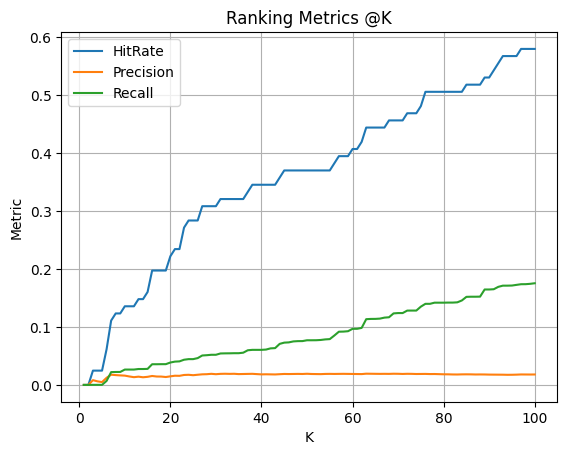

In [57]:
import matplotlib.pyplot as plt

plt.plot(metrics_df["k"], metrics_df["hitrate@k"], label="HitRate")
plt.plot(metrics_df["k"], metrics_df["precision@k"], label="Precision")
plt.plot(metrics_df["k"], metrics_df["recall@k"], label="Recall")

plt.xlabel("K")
plt.ylabel("Metric")
plt.title("Ranking Metrics @K")
plt.legend()
plt.grid()
plt.show()

# Scratchs

In [ ]:

def find_good_demo_users(
    positive_new_df,
    users,
    movie_ee_db,
    train_data,
    min_user_train_interactions=25,
    min_movie_train_ratings=10,
    top_k=25,
    max_users_to_check=500,
):
    candidates = positive_new_df[
        (positive_new_df["user_interactions_in_train"] >= min_user_train_interactions) &
        (positive_new_df["movie_ratings_in_train"] >= min_movie_train_ratings)
    ].copy()

    candidates = candidates.sort_values(
        ["user_interactions_in_train", "movie_ratings_in_train"],
        ascending=False,
    )

    rows = []

    for _, row in candidates.head(max_users_to_check).iterrows():
        user_id = row["user_id"]
        target_movie_id = row["movie_id"]

        user_df = users[users["user_id"] == user_id]
        if len(user_df) == 0:
            continue

        recs = recommend_movies_for_user_excluding_seen(
            user_df=user_df,
            movie_ee_db=movie_ee_db,
            train_data=train_data,
            top_k=top_k,
        )

        rec_movie_ids = recs["movie_id"].tolist()

        if target_movie_id in rec_movie_ids:
            rank = rec_movie_ids.index(target_movie_id) + 1

            rows.append({
                "user_id": user_id,
                "target_movie_id": target_movie_id,
                "target_movie_title": row.get("movie_title", None),
                "rank_in_recommendations": rank,
                "user_interactions_in_train": row["user_interactions_in_train"],
                "movie_ratings_in_train": row["movie_ratings_in_train"],
            })

    return pd.DataFrame(rows).sort_values("rank_in_recommendations")

In [ ]:
demo_users_df = find_good_demo_users(
    positive_new_df=positive_new_df,
    users=users,
    movie_ee_db=movie_ee_db,
    train_data=train_data,
    top_k=20,
)

# demo_users_df_unique = (
#     demo_users_df
#     .sort_values("rank_in_recommendations")   # best rank first
#     .drop_duplicates(subset=["user_id"])      # keep 1 per user
# )

demo_users_df.head(10)



In [ ]:
def find_good_demo_users(
    positive_new_df,
    users,
    movie_ee_db,
    train_data,
    min_user_train_interactions=50,
    min_movie_train_ratings=20,
    top_k=20,
    max_users_to_check=100,
):
    candidates = positive_new_df[
        (positive_new_df["user_interactions_in_train"] >= min_user_train_interactions) &
        (positive_new_df["movie_ratings_in_train"] >= min_movie_train_ratings)
    ].copy()

    candidates = candidates.sort_values(
        ["user_interactions_in_train", "movie_ratings_in_train"],
        ascending=False,
    )

    rows = []

    for _, row in candidates.head(max_users_to_check).iterrows():
        user_id = row["user_id"]
        target_movie_id = row["movie_id"]

        user_df = users[users["user_id"] == user_id]
        if len(user_df) == 0:
            continue

        recs = recommend_movies_for_user_excluding_seen(
            user_df=user_df,
            movie_ee_db=movie_ee_db,
            train_data=train_data,
            top_k=top_k,
        )

        rec_movie_ids = recs["movie_id"].tolist()

        if target_movie_id in rec_movie_ids:
            rank = rec_movie_ids.index(target_movie_id) + 1

            rows.append({
                "user_id": user_id,
                "target_movie_id": target_movie_id,
                "target_movie_title": row.get("movie_title", None),
                "rank_in_recommendations": rank,
                "user_interactions_in_train": row["user_interactions_in_train"],
                "movie_ratings_in_train": row["movie_ratings_in_train"],
            })

    cols = [
        "user_id",
        "target_movie_id",
        "target_movie_title",
        "rank_in_recommendations",
        "user_interactions_in_train",
        "movie_ratings_in_train",
    ]

    if len(rows) == 0:
        return pd.DataFrame(columns=cols)

    return pd.DataFrame(rows).sort_values("rank_in_recommendations")

USER_TO_EXCLUDE = b'416'

positive_new_df_filtered = positive_new_df[
    positive_new_df["user_id"] != USER_TO_EXCLUDE
]

users_filtered = users[
    users["user_id"] != USER_TO_EXCLUDE
]


demo_users_df = find_good_demo_users(
    positive_new_df=positive_new_df_filtered,
    users=users_filtered,
    movie_ee_db=movie_ee_db,
    train_data=train_data,
    top_k=100,
    min_user_train_interactions=20,
    min_movie_train_ratings=10,
    max_users_to_check=1000,
)

demo_users_df.head(10)

In [ ]:
# NOTE: user that watch a lot of movies and less picky
demo_user_id = b"416" # demo_users_df.iloc[0]["user_id"]
demo_user = users[users["user_id"] == demo_user_id]

recommend_movies_for_user_excluding_seen(
    demo_user,
    movie_ee_db,
    train_data,
    top_k=10,
)

print()
test_with_no_cold_start[test_with_no_cold_start.user_id == demo_user_id]

In [ ]:
# NOTE: user that watch a lot of movies and less picky
demo_user_id = b'186'
demo_user = users[users["user_id"] == demo_user_id]

recommend_movies_for_user_excluding_seen(
    demo_user,
    movie_ee_db,
    train_data,
    top_k=10,
)

print()
test_with_no_cold_start[test_with_no_cold_start.user_id == demo_user_id]

In [ ]:
recommendations = recommend_movies_for_user(
    user_df=user_horror_fan2,
    movie_ee_db=movie_ee_db,
    top_k=5,
)

recommendations[["movie_id", "movie_title", "score"]]